In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score
from scipy import stats

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import seasonal_decompose

In [81]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


In [8]:
missing_values = df.isnull().sum()

missing_values

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
#No missing values

In [10]:
df = df.drop_duplicates()

In [11]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-01'
)

df = df.sort_values('Date')

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
872,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
2215,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


In [12]:
numerical_cols = df.select_dtypes(include=np.number).columns

categorical_cols = df.select_dtypes(include='object').columns

print("Numerical Features:")
print(numerical_cols)

print("\nCategorical Features:")
print(categorical_cols)

Numerical Features:
Index(['Year', 'Month', 'Estimated_Deliveries', 'Production_Units',
       'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations'],
      dtype='object')

Categorical Features:
Index(['Region', 'Model', 'Source_Type'], dtype='object')


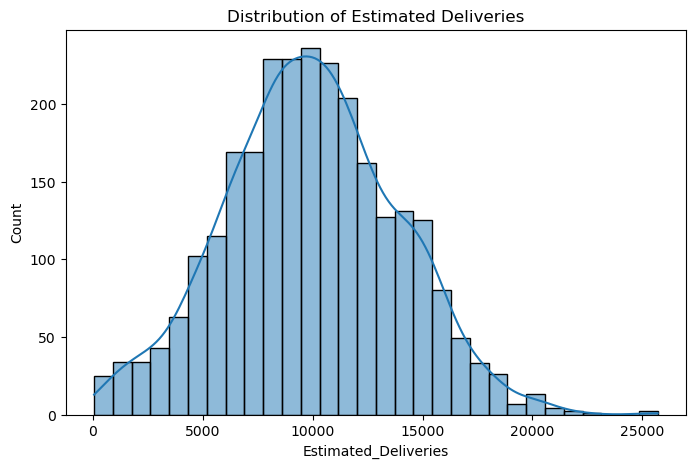

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Estimated_Deliveries'],
    kde=True,
    bins=30
)

plt.title("Distribution of Estimated Deliveries")
plt.show()

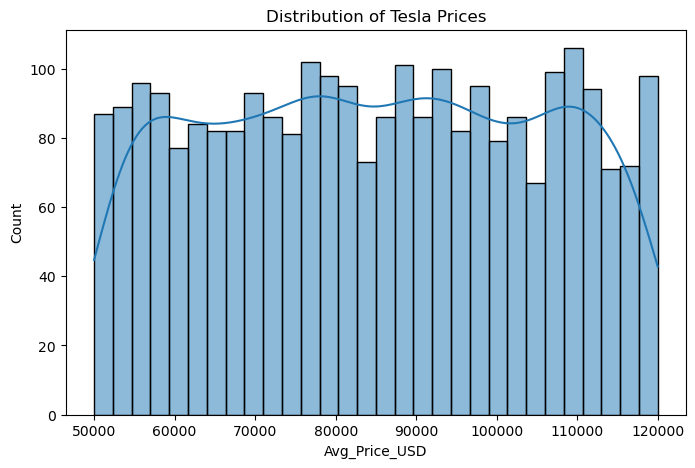

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Avg_Price_USD'],
    kde=True,
    bins=30
)

plt.title("Distribution of Tesla Prices")
plt.show()

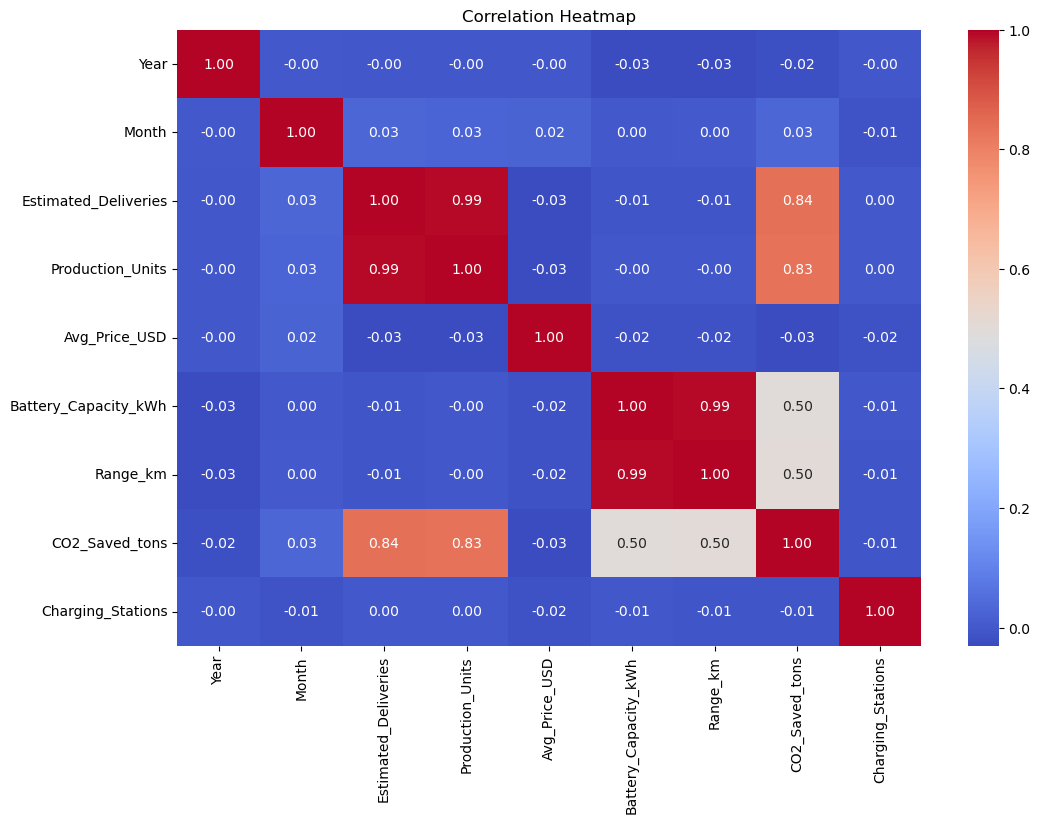

In [15]:
plt.figure(figsize=(12,8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

In [79]:
target_corr = corr_matrix['Estimated_Deliveries'].sort_values(
    ascending=False
)
print(target_corr)

Estimated_Deliveries    1.000000
Production_Units        0.994234
CO2_Saved_tons          0.836814
Month                   0.030877
Charging_Stations       0.000753
Year                   -0.002863
Range_km               -0.006606
Battery_Capacity_kWh   -0.007765
Avg_Price_USD          -0.027546
Name: Estimated_Deliveries, dtype: float64


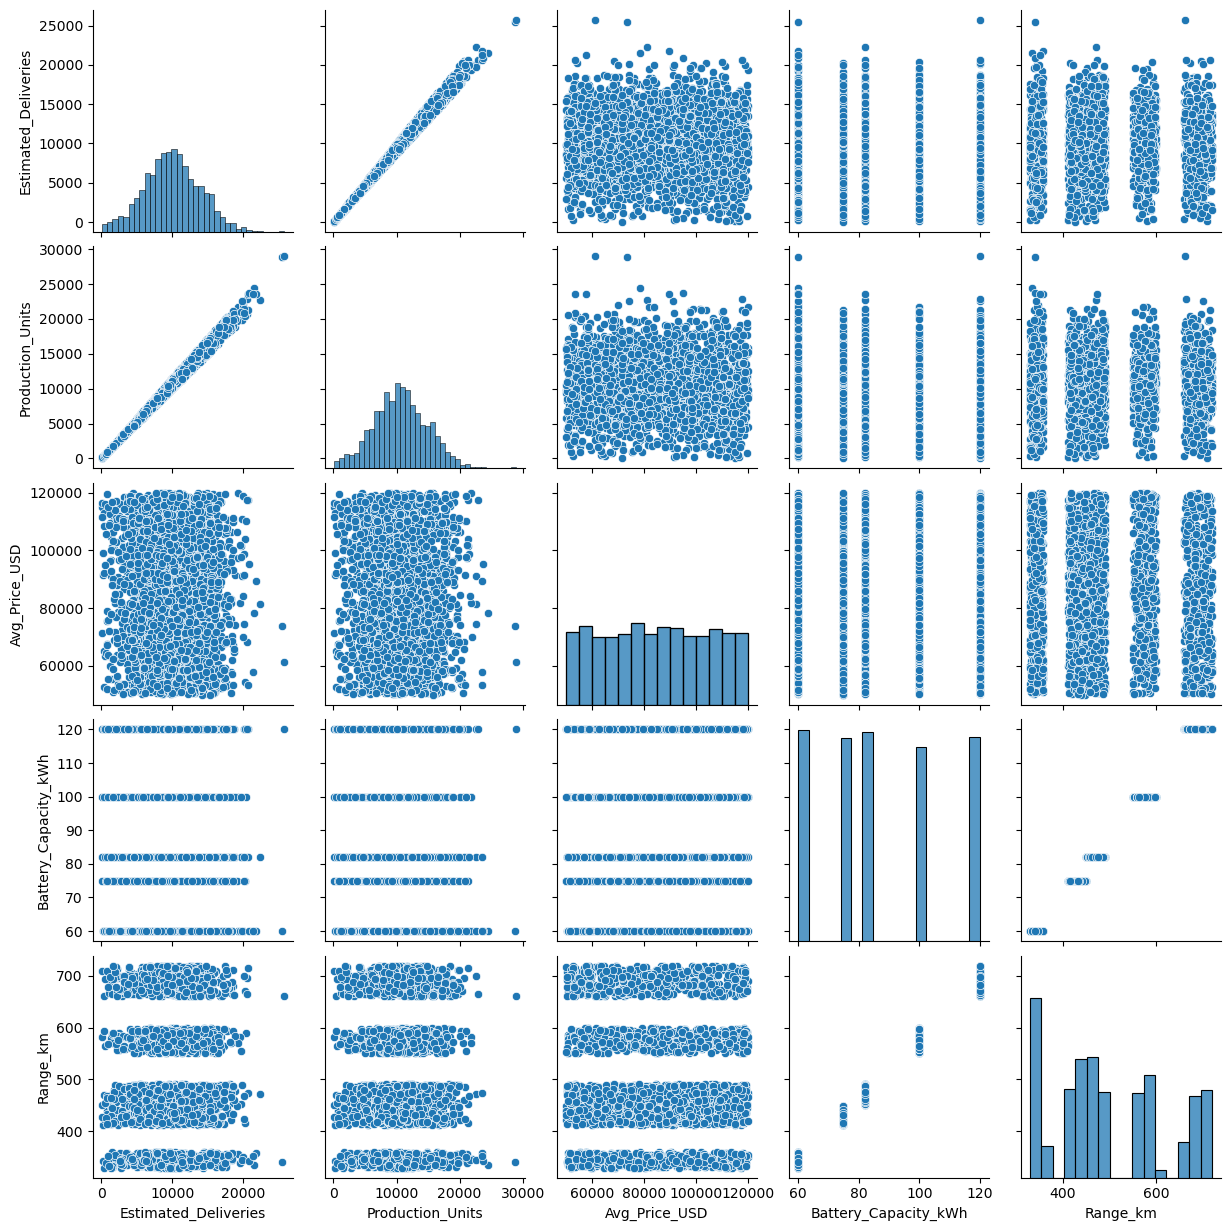

In [17]:
selected_features = [
    'Estimated_Deliveries',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km'
]
sns.pairplot(df[selected_features])

plt.show()

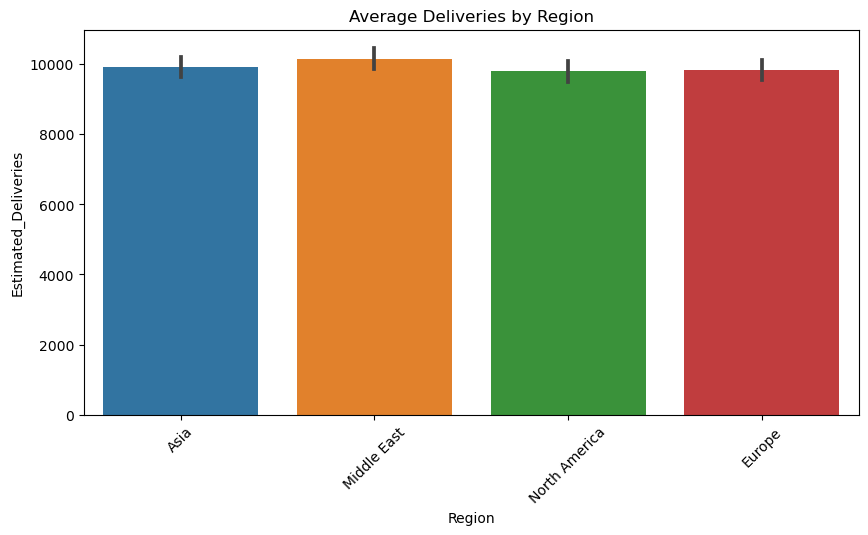

In [19]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Region',
    y='Estimated_Deliveries',
    data=df,
    estimator=np.mean
)

plt.xticks(rotation=45)

plt.title("Average Deliveries by Region")

plt.show()

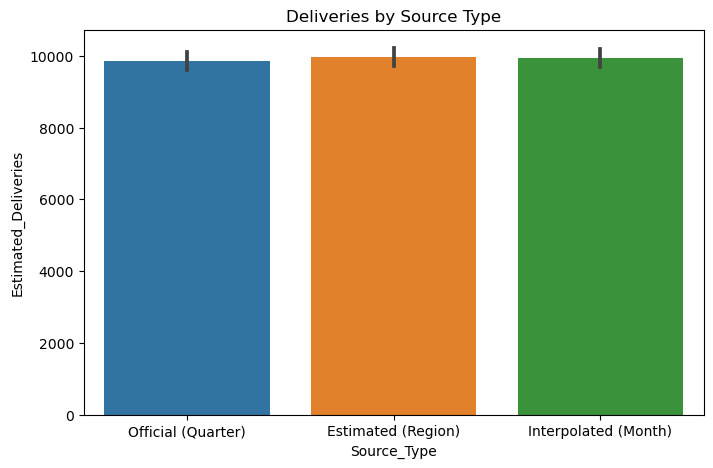

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Source_Type',
    y='Estimated_Deliveries',
    data=df,
    estimator=np.mean
)

plt.title("Deliveries by Source Type")

plt.show()

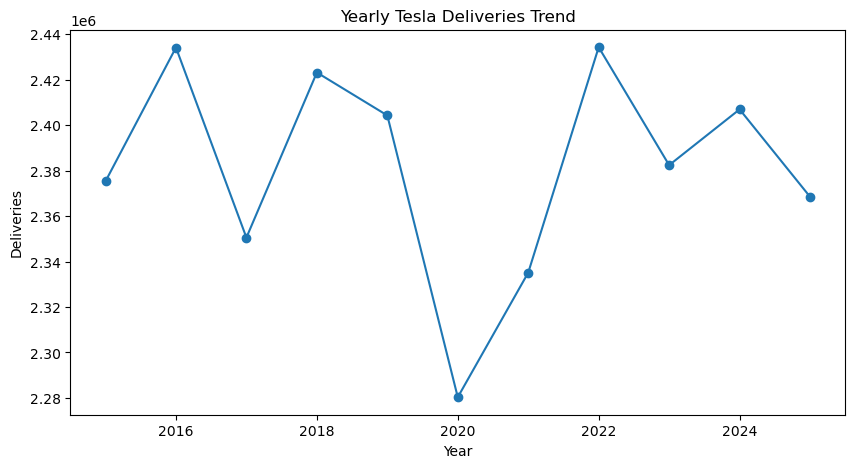

In [21]:
yearly_sales = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10,5))

yearly_sales.plot(marker='o')

plt.title("Yearly Tesla Deliveries Trend")

plt.ylabel("Deliveries")

plt.show()

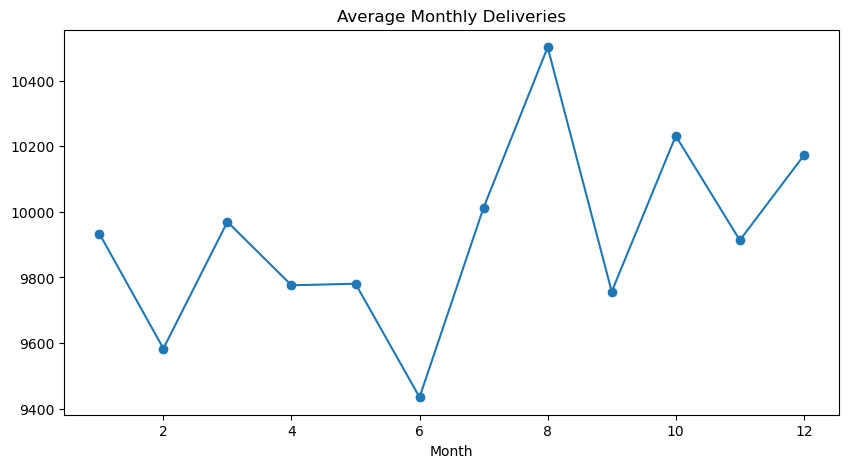

In [22]:
monthly_sales = df.groupby('Month')['Estimated_Deliveries'].mean()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Average Monthly Deliveries")

plt.show()

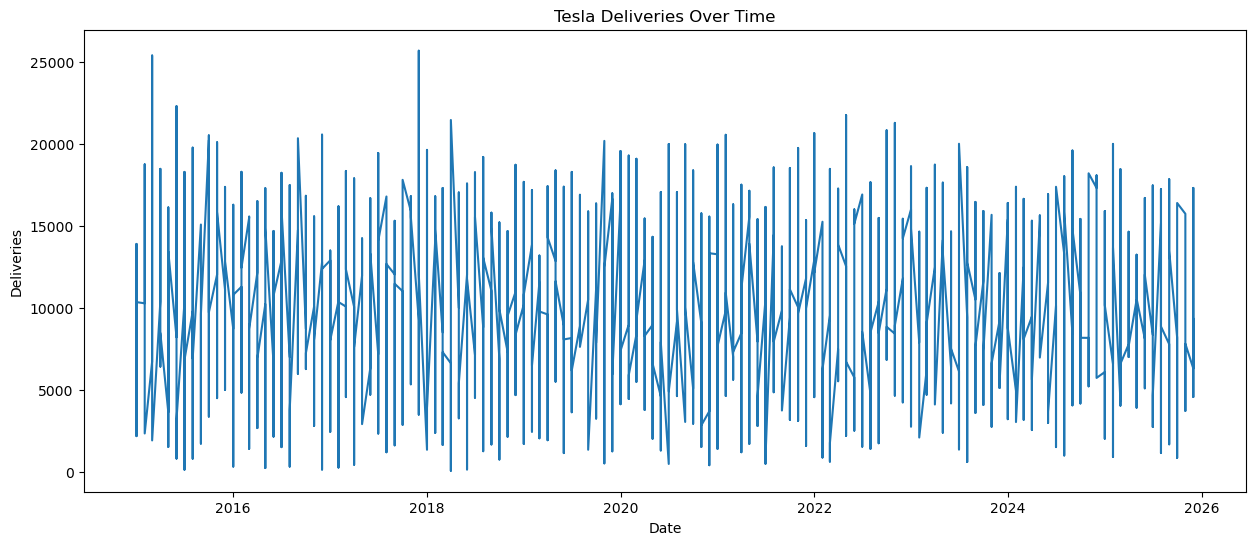

In [23]:
plt.figure(figsize=(15,6))

plt.plot(
    df['Date'],
    df['Estimated_Deliveries']
)

plt.title("Tesla Deliveries Over Time")

plt.xlabel("Date")
plt.ylabel("Deliveries")

plt.show()

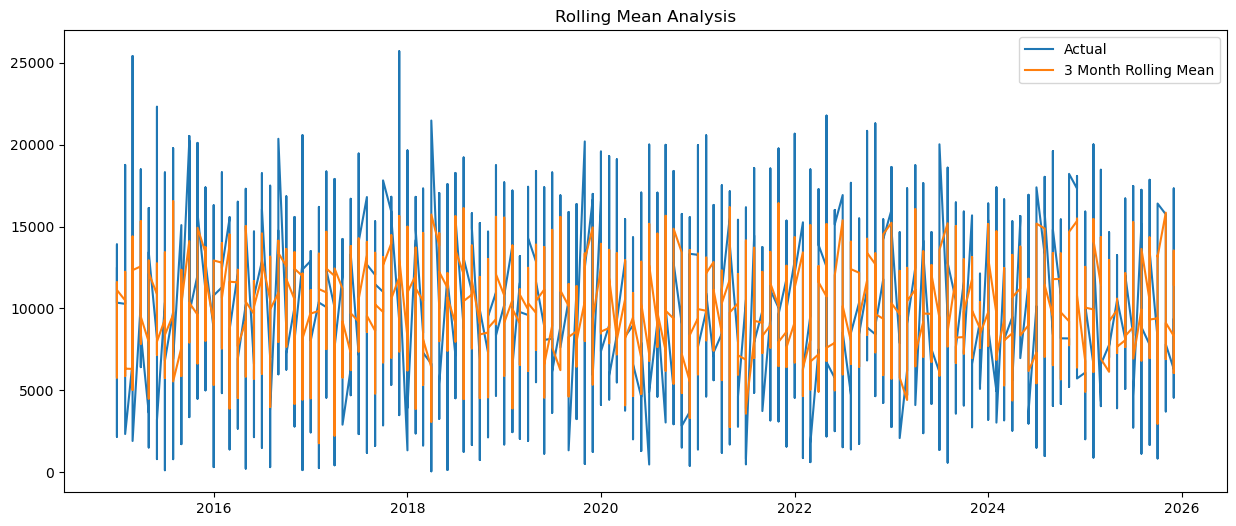

In [25]:
df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    df['Date'],
    df['Estimated_Deliveries'],
    label='Actual'
)

plt.plot(
    df['Date'],
    df['Rolling_Mean_3'],
    label='3 Month Rolling Mean'
)

plt.legend()

plt.title("Rolling Mean Analysis")

plt.show()

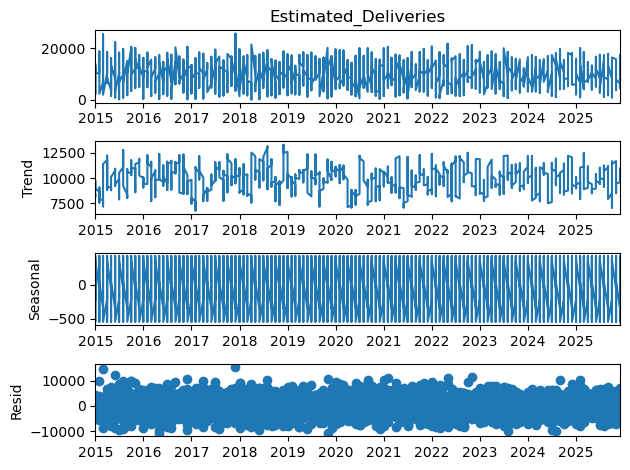

In [27]:
temp = df.set_index('Date')

decomposition = seasonal_decompose(
    temp['Estimated_Deliveries'],
    model='additive',
    period=12
)

decomposition.plot()

plt.show()

In [30]:
df['Lag_1'] = df['Estimated_Deliveries'].shift(1)

df['Lag_3'] = df['Estimated_Deliveries'].shift(3)

df['Lag_6'] = df['Estimated_Deliveries'].shift(6)

df[['Estimated_Deliveries',
    'Lag_1',
    'Lag_3',
    'Lag_6']].head(10)

,Estimated_Deliveries,Lag_1,Lag_3,Lag_6
872,12446,NaN,NaN,NaN
2354,11446,12446.0,NaN,NaN
2312,8803,11446.0,NaN,NaN
2293,6367,8803.0,12446.0,NaN
2215,8795,6367.0,11446.0,NaN
2065,2161,8795.0,8803.0,NaN
2023,11986,2161.0,6367.0,12446.0
1872,8833,11986.0,8795.0,11446.0
2469,9446,8833.0,2161.0,8803.0
1766,4350,9446.0,11986.0,6367.0


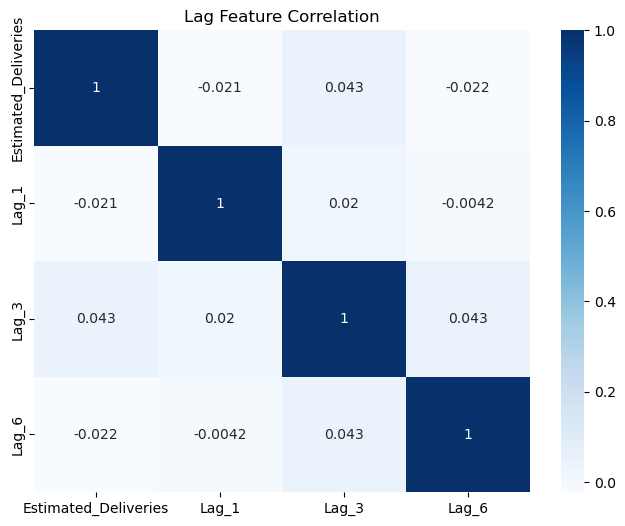

In [31]:
lag_features = [
    'Estimated_Deliveries',
    'Lag_1',
    'Lag_3',
    'Lag_6'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[lag_features].corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Lag Feature Correlation")

plt.show()

In [80]:
drop_cols = [
    'Date',
    'Estimated_Deliveries',
    'Range_km'  
]
X = df.drop(columns=['Estimated_Deliveries','Date'])
y = df['Estimated_Deliveries']

In [63]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [64]:
categorical_features = [
    'Region',
    'Model',
    'Source_Type'
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

In [65]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

In [66]:
linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [67]:
linear_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Month',
                                                   'Production_Units',
                                                   'Avg_Price_USD',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations',
                                                   'Rolling_Mean_3', 'Lag_1',
                                                   'Lag_3', 'Lag_6']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Region', 'Model',
                                                   'Source_Type'])])),
                ('model', LinearRegression())])

In [78]:
y_pred = linear_pipeline.predict(X_test)

In [70]:

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,4))

MAE : 322.15
RMSE: 391.58
R²  : 0.9885


In [73]:
tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(
    linear_pipeline,
    X,
    y,
    cv=tscv,
    scoring='r2'
)

print("CV R² Scores:")
print(cv_scores)

print("Mean CV R²:",
      cv_scores.mean())

CV R² Scores:
[0.99062608 0.99061478 0.99093017 0.99046219 0.98857373]
Mean CV R²: 0.9902413890288326


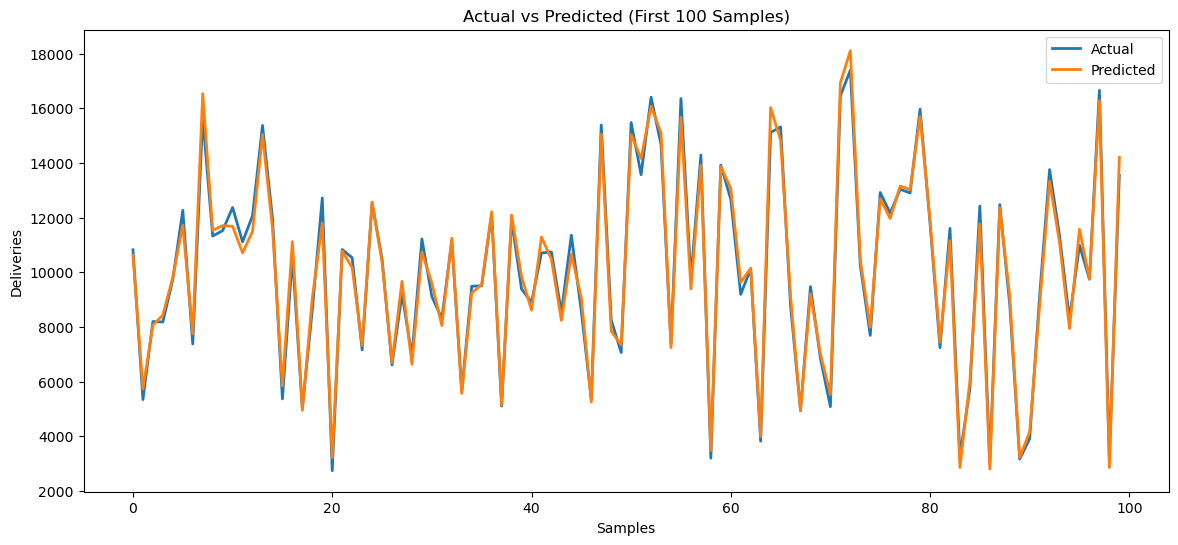

In [75]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:100],
    label='Actual',
    linewidth=2
)

plt.plot(
    y_pred[:100],
    label='Predicted',
    linewidth=2
)

plt.title('Actual vs Predicted (First 100 Samples)')
plt.xlabel('Samples')
plt.ylabel('Deliveries')

plt.legend()
plt.show()

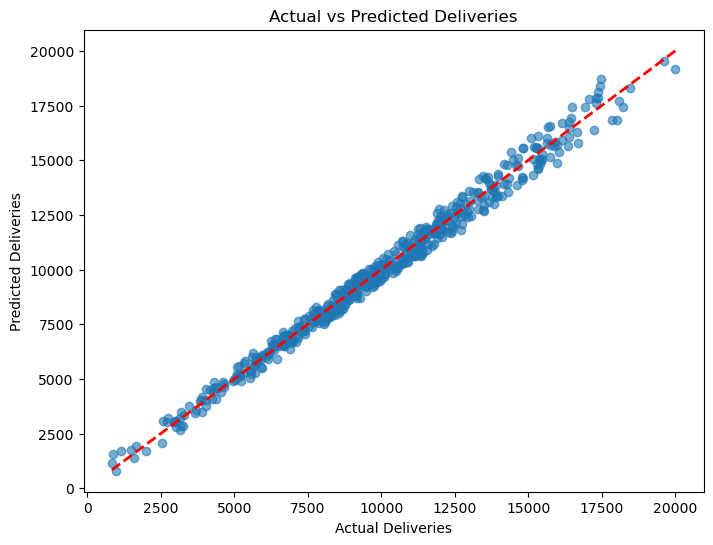

In [76]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2
)

plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.title('Actual vs Predicted Deliveries')

plt.show()

In [ ]:
'''Insights:
1. Production_Units is the dominant predictor (r = 0.99)
2. Battery_Capacity_kWh and Range_km are highly redundant (r = 0.99)
3. Price has almost no influence on deliveries.
4. Lag features provide little predictive value.
5. The dataset shows weak temporal dependence, making forecasting challenging.
6. Multicollinearity exists, justifying Ridge and Lasso Regression.'''